In [ ]:
%pip install gdown matplotlib
!gdown "1_wv4XFBYoeynXyS8aUb5AH2Cr3fMNbNW"
!gdown "1p50Vn4PGaKlPdPQdooFT0W6GXsz2a0Se"
%pip install -r requirements.txt

In [ ]:
import torch
from torch import nn, optim
from torch.utils.data import DataLoader
from transformers import CLIPTextModel, CLIPTokenizer, AutoModel, AutoTokenizer
from datasets import load_dataset
import torch.nn.functional as F
import matplotlib.pyplot as plt

In [ ]:
%run tools.py

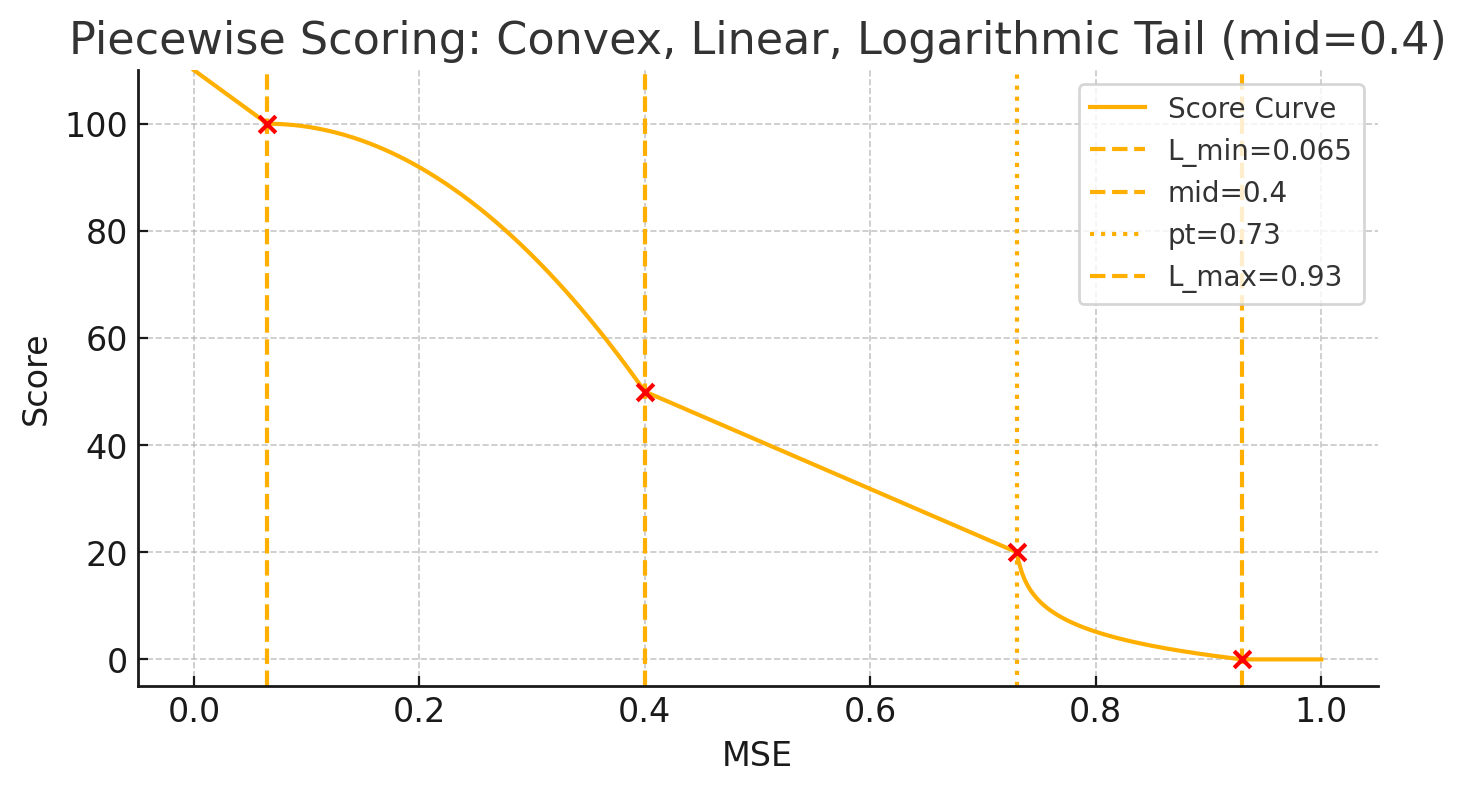

In [ ]:
import numpy as np


def curved_score_calibrated(mse,
                            L_min=0.065,
                            mid=0.4,
                            pt=0.73,
                            L_max=0.93,
                            P_max=100,
                            bonus_max=10,
                            S_mid=50,
                            S_pt=20,
                            exp1=2.0,
                            alpha=50):
    if mse < 0:
        raise ValueError("MSE cannot be negative")
    # Bonus region
    if mse < L_min:
        bonus = bonus_max * (L_min - mse) / L_min
        return P_max + bonus
    # Zero floor
    if mse >= L_max:
        return 0.0
    # Convex segment [L_min, mid]
    if mse < mid:
        norm = (mse - L_min) / (mid - L_min)
        return P_max - (P_max - S_mid) * norm**exp1
    # Linear segment [mid, pt]
    if mse < pt:
        norm = (mse - mid) / (pt - mid)
        return S_mid + (S_pt - S_mid) * norm
    # Logarithmic segment [pt, L_max]
    z = (mse - pt) / (L_max - pt)
    return S_pt * (1 - np.log1p(alpha * z) / np.log1p(alpha))

In [ ]:
BATCH_SIZE = 64
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_id = "sd-legacy/stable-diffusion-v1-5"

In [ ]:
ds = load_dataset(
    "json",
    data_files={
        "test": "./test.json"
    }
)

dataset_test = ds["test"]

In [ ]:
clip_tokenizer = CLIPTokenizer.from_pretrained(model_id,
    subfolder="tokenizer",        # points to the tokenizer files
    use_fast=True  )
clip_text_encoder = CLIPTextModel.from_pretrained(model_id,
    subfolder="text_encoder" ).to(DEVICE)
clip_text_encoder.eval()
bg_tokenizer = AutoTokenizer.from_pretrained('rmihaylov/roberta-base-nli-stsb-theseus-bg')
bg_encoder = AutoModel.from_pretrained('rmihaylov/roberta-base-nli-stsb-theseus-bg').to(DEVICE)
bg_encoder.eval()
with torch.no_grad():
    dummy_bg = bg_tokenizer(['тест'], return_tensors='pt', padding=True)
    bg_dim = bg_encoder(**{k: v.to(DEVICE) for k, v in dummy_bg.items()}).last_hidden_state.size(-1)
    dummy_en = clip_tokenizer(['test'], return_tensors='pt', padding=True)
    clip_dim = clip_text_encoder(**{k: v.to(DEVICE) for k, v in dummy_en.items()})[0].size(-1)

In [ ]:
class Projector(nn.Module):
    def __init__(self, bg_dim, clip_dim=512, len_tokens=77, dropout_rate=0.15):
        super().__init__()
        self.len_tokens = len_tokens
        self.clip_dim = clip_dim
        self.bg_dim = bg_dim
        self.shift_k = 1  # Фиксиран цикличен сдвиг

        # Learnable positional embeddings
        self.pos_embed = nn.Parameter(torch.randn(1, len_tokens, bg_dim))

        # MLP с LayerNorm и Dropout за възстановяване
        self.recover_net = nn.Sequential(
            nn.Linear(bg_dim, bg_dim // 2),
            nn.ReLU(),
            nn.LayerNorm(bg_dim // 2),
            nn.Dropout(dropout_rate),
            nn.Linear(bg_dim // 2, bg_dim),
            nn.LayerNorm(bg_dim),
            nn.Dropout(dropout_rate),
        )

        # Transformer encoder с dropout
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=bg_dim,
            nhead=8,
            dim_feedforward=4 * bg_dim,
            dropout=dropout_rate,
            activation='gelu',
            batch_first=True,
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=4)

        # Финална линейна проекция към CLIP пространство
        self.projector = nn.Linear(bg_dim, clip_dim)

    def forward(self, hidden_states, attention_mask=None):
        # 1. Undo circular shift (наляво)
        x = torch.roll(hidden_states, shifts=-self.shift_k, dims=1)

        # 2. Възстановяване на dropout damage
        x = self.recover_net(x)

        # 3. Падинг или съкращаване до len_tokens
        seq_len = x.size(1)
        if seq_len < self.len_tokens:
            pad_token = x[:, -1:, :]
            x = torch.cat([x, pad_token.repeat(1, self.len_tokens - seq_len, 1)], dim=1)
        elif seq_len > self.len_tokens:
            x = x[:, :self.len_tokens, :]

        # 4. Добавяне на позиционни ембединг
        x = x + self.pos_embed[:, :self.len_tokens, :]

        # 5. Transformer реконструкция
        x = self.transformer(x)

        # 6. Проекция към CLIP embedding
        return self.projector(x)

In [ ]:
!pwd

In [ ]:
proj = Projector(bg_dim, clip_dim).to(DEVICE)
proj.load_state_dict(torch.load("./proj_state_dict_task_2_sample.pth")) #SET THE PATH TO THE CHECKPOINT
proj.eval()
test_loader = DataLoader(
    dataset_test,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=lambda batch: (
        bg_tokenizer([x['bg'].lower() for x in batch], padding=True, truncation=True, return_tensors='pt'),
        clip_tokenizer([x['en'].lower() for x in batch], padding=True, truncation=True, return_tensors='pt')
    )
)

In [ ]:
val_loss = validate(proj, test_loader, bg_encoder, clip_text_encoder, DEVICE)
print(f"Validation score: {val_loss:.4f}\nFinal Score: {curved_score_calibrated(val_loss):.2f}")